## Phần 5 - Mô hình phân loại dựa trên LSTM/GRU

- Dùng CIFAR-10
- Biến ảnh thành chuỗi để huấn luyện mô hình RNN.
- So sánh 2 mô hình: `LSTM` và `GRU`.

In [1]:
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tqdm import tqdm


# Cố định seed để kết quả giữa các lần chạy ổn định hơn.
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


# Gom toàn bộ siêu tham số vào một chỗ để dễ tinh chỉnh.
class Config:
    data_root = "./data"
    batch_size = 128
    lr = 2e-3
    weight_decay = 1e-4
    epochs = 15
    num_workers = 2
    num_classes = 10

    # RNN config
    hidden_size = 256
    num_layers = 2
    dropout = 0.3
    bidirectional = True
    patch_size = 4

    # training tricks
    grad_clip = 1.0
    label_smoothing = 0.1


cfg = Config()
set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [2]:
# Load dữ liệu theo cách tham chiếu từ notebook phần 1-2.
# Train dùng augment, còn val/test giữ transform cố định để đánh giá công bằng.
augment_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

# Tạo split chỉ số một lần để train/val nhất quán qua các dataset clone.
base_train_dataset = datasets.CIFAR10(
    root=cfg.data_root,
    train=True,
    download=True,
    transform=eval_transform,
)

n = len(base_train_dataset)
indices = torch.randperm(n, generator=torch.Generator().manual_seed(42)).tolist()
train_size = int(0.8 * n)
train_idx, val_idx = indices[:train_size], indices[train_size:]

# Dùng 2 dataset khác nhau để tránh mất augment ở tập train.
train_dataset_full = datasets.CIFAR10(
    root=cfg.data_root,
    train=True,
    download=False,
    transform=augment_transform,
)
val_dataset_full = datasets.CIFAR10(
    root=cfg.data_root,
    train=True,
    download=False,
    transform=eval_transform,
)

test_dataset = datasets.CIFAR10(
    root=cfg.data_root,
    train=False,
    download=True,
    transform=eval_transform,
)

train_dataset = Subset(train_dataset_full, train_idx)
val_dataset = Subset(val_dataset_full, val_idx)

# DataLoader: train shuffle=True, val/test shuffle=False.
gen = torch.Generator().manual_seed(42)
train_loader = DataLoader(
    train_dataset,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=cfg.num_workers,
    pin_memory=torch.cuda.is_available(),
    generator=gen,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=torch.cuda.is_available(),
)
test_loader = DataLoader(
    test_dataset,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=torch.cuda.is_available(),
)

classes = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

print(f"Train/Val/Test: {len(train_dataset)}/{len(val_dataset)}/{len(test_dataset)}")

/Users/lyminhtrung/.conda/envs/conda/lib/python3.13/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train/Val/Test: 40000/10000/10000


In [3]:
class ImageSequenceEncoder(nn.Module):
    """Chuyển ảnh 3x32x32 thành chuỗi theo row, col hoặc patch."""

    def __init__(self, seq_mode="row", patch_size=4):
        super().__init__()
        if seq_mode not in {"row", "col", "patch"}:
            raise ValueError("seq_mode must be 'row', 'col', or 'patch'")
        self.seq_mode = seq_mode
        self.patch_size = patch_size

    def feature_size(self):
        # Kích thước vector đặc trưng của mỗi time-step.
        if self.seq_mode in {"row", "col"}:
            return 3 * 32
        return 3 * self.patch_size * self.patch_size

    def forward(self, x):
        # x: (B, C, H, W) = (B, 3, 32, 32)
        if self.seq_mode == "row":
            # Mỗi bước thời gian là 1 hàng ảnh.
            return x.permute(0, 2, 1, 3).contiguous().view(x.size(0), x.size(2), -1)

        if self.seq_mode == "col":
            # Mỗi bước thời gian là 1 cột ảnh.
            return x.permute(0, 3, 1, 2).contiguous().view(x.size(0), x.size(3), -1)

        # Patch sequence: giảm chiều dài chuỗi, thường ổn định hơn cho RNN.
        p = self.patch_size
        patches = x.unfold(2, p, p).unfold(3, p, p)                  # (B, C, H/p, W/p, p, p)
        patches = patches.contiguous().view(x.size(0), x.size(1), -1, p, p)
        seq = patches.permute(0, 2, 1, 3, 4).reshape(x.size(0), -1, x.size(1) * p * p)
        return seq


class LSTMClassifier(nn.Module):
    def __init__(
        self,
        num_classes=10,
        hidden_size=256,
        num_layers=2,
        dropout=0.3,
        bidirectional=True,
        seq_mode="row",
        patch_size=4,
    ):
        super().__init__()
        self.encoder = ImageSequenceEncoder(seq_mode=seq_mode, patch_size=patch_size)
        input_size = self.encoder.feature_size()

        self.rnn = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional,
        )

        out_dim = hidden_size * (2 if bidirectional else 1)
        # Ghép last/mean/max để tăng thông tin ngữ cảnh trước khi phân loại.
        head_in = out_dim * 3
        self.head = nn.Sequential(
            nn.LayerNorm(head_in),
            nn.Dropout(dropout),
            nn.Linear(head_in, num_classes),
        )

    def forward(self, x):
        seq = self.encoder(x)                                   # (B, T, F)
        out, _ = self.rnn(seq)                                  # (B, T, H)
        last = out[:, -1, :]
        mean_pool = out.mean(dim=1)
        max_pool = out.max(dim=1).values
        feat = torch.cat([last, mean_pool, max_pool], dim=1)
        return self.head(feat)


class GRUClassifier(nn.Module):
    def __init__(
        self,
        num_classes=10,
        hidden_size=256,
        num_layers=2,
        dropout=0.3,
        bidirectional=True,
        seq_mode="row",
        patch_size=4,
    ):
        super().__init__()
        self.encoder = ImageSequenceEncoder(seq_mode=seq_mode, patch_size=patch_size)
        input_size = self.encoder.feature_size()

        self.rnn = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional,
        )

        out_dim = hidden_size * (2 if bidirectional else 1)
        head_in = out_dim * 3
        self.head = nn.Sequential(
            nn.LayerNorm(head_in),
            nn.Dropout(dropout),
            nn.Linear(head_in, num_classes),
        )

    def forward(self, x):
        seq = self.encoder(x)                                   # (B, T, F)
        out, _ = self.rnn(seq)                                  # (B, T, H)
        last = out[:, -1, :]
        mean_pool = out.mean(dim=1)
        max_pool = out.max(dim=1).values
        feat = torch.cat([last, mean_pool, max_pool], dim=1)
        return self.head(feat)

In [4]:
def evaluate(model, loader):
    """Đánh giá model trên một dataloader và trả về các metric chính."""
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            preds = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average="macro", zero_division=0)
    recall = recall_score(all_labels, all_preds, average="macro", zero_division=0)
    f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    return acc, precision, recall, f1


def train_one_model(model, name, train_loader, val_loader, epochs=5, lr=1e-3):
    """Huấn luyện 1 model và lưu lại checkpoint có val_f1 tốt nhất."""
    model = model.to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=cfg.label_smoothing)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=cfg.weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    # AMP chỉ bật khi có CUDA để tăng tốc/giảm RAM GPU.
    use_amp = torch.cuda.is_available()
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

    best_f1 = -1.0
    best_state = None
    history = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for images, labels in tqdm(train_loader, desc=f"{name} | Epoch {epoch+1}/{epochs}", leave=False):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad(set_to_none=True)
            with torch.autocast(device_type="cuda", enabled=use_amp):
                logits = model(images)
                loss = criterion(logits, labels)

            # Backprop + clip gradient để tránh exploding gradients trong RNN.
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item()

        scheduler.step()
        train_loss = running_loss / len(train_loader)
        val_acc, val_precision, val_recall, val_f1 = evaluate(model, val_loader)

        history.append({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "val_acc": val_acc,
            "val_precision": val_precision,
            "val_recall": val_recall,
            "val_f1": val_f1,
            "lr": optimizer.param_groups[0]["lr"],
        })

        if val_f1 > best_f1:
            best_f1 = val_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        print(
            f"{name} | epoch {epoch+1:02d} | "
            f"loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_f1={val_f1:.4f} | "
            f"lr={optimizer.param_groups[0]['lr']:.2e}"
        )

    model.load_state_dict(best_state)
    return model, history


# So sánh theo kiểu chuỗi (row/patch) và theo loại RNN (LSTM/GRU).
models = {
    "LSTM_row": LSTMClassifier(
        num_classes=cfg.num_classes,
        hidden_size=cfg.hidden_size,
        num_layers=cfg.num_layers,
        dropout=cfg.dropout,
        bidirectional=cfg.bidirectional,
        seq_mode="row",
        patch_size=cfg.patch_size,
    ),
    "GRU_row": GRUClassifier(
        num_classes=cfg.num_classes,
        hidden_size=cfg.hidden_size,
        num_layers=cfg.num_layers,
        dropout=cfg.dropout,
        bidirectional=cfg.bidirectional,
        seq_mode="row",
        patch_size=cfg.patch_size,
    ),
    "LSTM_patch": LSTMClassifier(
        num_classes=cfg.num_classes,
        hidden_size=cfg.hidden_size,
        num_layers=cfg.num_layers,
        dropout=cfg.dropout,
        bidirectional=cfg.bidirectional,
        seq_mode="patch",
        patch_size=cfg.patch_size,
    ),
    "GRU_patch": GRUClassifier(
        num_classes=cfg.num_classes,
        hidden_size=cfg.hidden_size,
        num_layers=cfg.num_layers,
        dropout=cfg.dropout,
        bidirectional=cfg.bidirectional,
        seq_mode="patch",
        patch_size=cfg.patch_size,
    ),
}

results = []
all_histories = {}

for name, model in models.items():
    print(f"\n===== Training {name} =====")
    trained_model, history = train_one_model(
        model,
        name,
        train_loader,
        val_loader,
        epochs=cfg.epochs,
        lr=cfg.lr,
    )
    all_histories[name] = history

    # Đánh giá cuối cùng trên test set.
    test_acc, test_precision, test_recall, test_f1 = evaluate(trained_model, test_loader)
    results.append({
        "Model": name,
        "Test Accuracy": test_acc,
        "Test Precision": test_precision,
        "Test Recall": test_recall,
        "Test F1": test_f1,
    })

results_df = pd.DataFrame(results).sort_values(by="Test F1", ascending=False).reset_index(drop=True)
results_df


===== Training LSTM_row =====


LSTM_row | epoch 01 | loss=2.0177 | val_acc=0.4259 | val_f1=0.4164 | lr=1.98e-03


LSTM_row | epoch 02 | loss=1.7737 | val_acc=0.4909 | val_f1=0.4816 | lr=1.91e-03


LSTM_row | epoch 03 | loss=1.6723 | val_acc=0.5113 | val_f1=0.5006 | lr=1.81e-03


LSTM_row | epoch 04 | loss=1.6043 | val_acc=0.5390 | val_f1=0.5324 | lr=1.67e-03


...

GRU_patch | epoch 12 | loss=1.1869 | val_acc=0.6813 | val_f1=0.6791 | lr=1.91e-04


GRU_patch | epoch 13 | loss=1.1650 | val_acc=0.6871 | val_f1=0.6856 | lr=8.65e-05


GRU_patch | epoch 14 | loss=1.1489 | val_acc=0.6893 | val_f1=0.6881 | lr=2.19e-05


GRU_patch | epoch 15 | loss=1.1461 | val_acc=0.6911 | val_f1=0.6892 | lr=0.00e+00


,Model,Test Accuracy,Test Precision,Test Recall,Test F1
0,LSTM_patch,0.6983,0.698253,0.6983,0.697583
1,GRU_patch,0.6839,0.681997,0.6839,0.682629
2,LSTM_row,0.6678,0.667447,0.6678,0.667051
3,GRU_row,0.6571,0.653357,0.6571,0.654376


## Kết luận và nhận xét

### 1. Kết luận chính
- Mục tiêu phần 5 đã được thực hiện: phân loại ảnh CIFAR-10 bằng các kiến trúc RNN (LSTM/GRU) khi chuyển ảnh sang dữ liệu chuỗi.
- Cả 4 mô hình đều học tốt: `train_loss` giảm đều qua các epoch, đồng thời `val_acc` và `val_f1` tăng ổn định.
- Mô hình tốt nhất trong thí nghiệm hiện tại là **LSTM_patch** với **Test F1 xấp xỉ 0.698**.
- Thứ tự hiệu năng theo Test F1:
  - `LSTM_patch` (~0.698)
  - `GRU_patch` (~0.683)
  - `LSTM_row` (~0.667)
  - `GRU_row` (~0.654)

### 2. Nhận xét từ kết quả
- Cách biểu diễn ảnh theo **patch sequence** cho kết quả tốt hơn **row sequence** với cả LSTM và GRU.
- LSTM cho kết quả nhỉnh hơn GRU trong cùng kiểu biểu diễn đầu vào.
- Các đường cong validation tăng dần và bắt đầu chững ở các epoch cuối, cho thấy mô hình đã gần hội tụ với cấu hình hiện tại.

### 3. Ý nghĩa thực nghiệm
- RNN vẫn có thể đạt hiệu quả khá cho CIFAR-10 nếu thiết kế biểu diễn chuỗi hợp lý.
- Tuy nhiên, do bản chất bài toán ảnh 2D, các mô hình chuyên biệt như CNN/ViT thường vẫn có lợi thế hơn về trích xuất đặc trưng không gian.

### 4. Hướng cải thiện tiếp theo
- Tăng `epochs` (20-30) và tinh chỉnh `hidden_size`, `num_layers`, `dropout`.
- Thử `patch_size` khác (2 hoặc 8) để cân bằng giữa độ dài chuỗi và lượng thông tin mỗi bước.
- Bổ sung confusion matrix và phân tích lỗi theo từng lớp để hiểu rõ điểm yếu của mô hình.
- So sánh thêm với một baseline CNN để làm nổi bật ưu/nhược điểm của hướng RNN.

### Biểu đồ kết quả train
- Cell bên dưới hiển thị learning curves (`train_loss`, `val_acc`, `val_f1`) và biểu đồ cột `Test F1` để trực quan hóa kết quả.

Saving images to: /Users/lyminhtrung/Library/CloudStorage/OneDrive-hcmut.edu.vn/DL-CV/CO5085_DeepLearning_CV/exercise/latex/images
Saved: part5_learning_curves.png


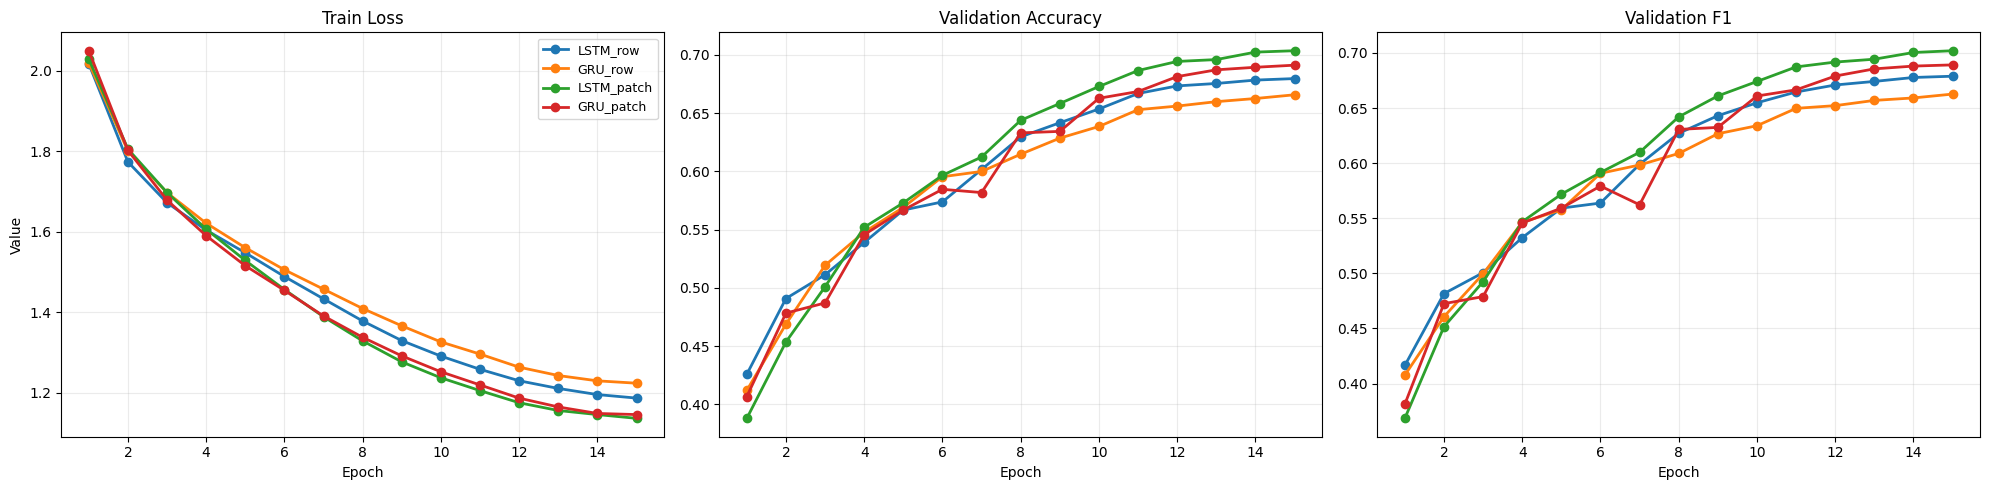

Saved: part5_test_f1_comparison.png


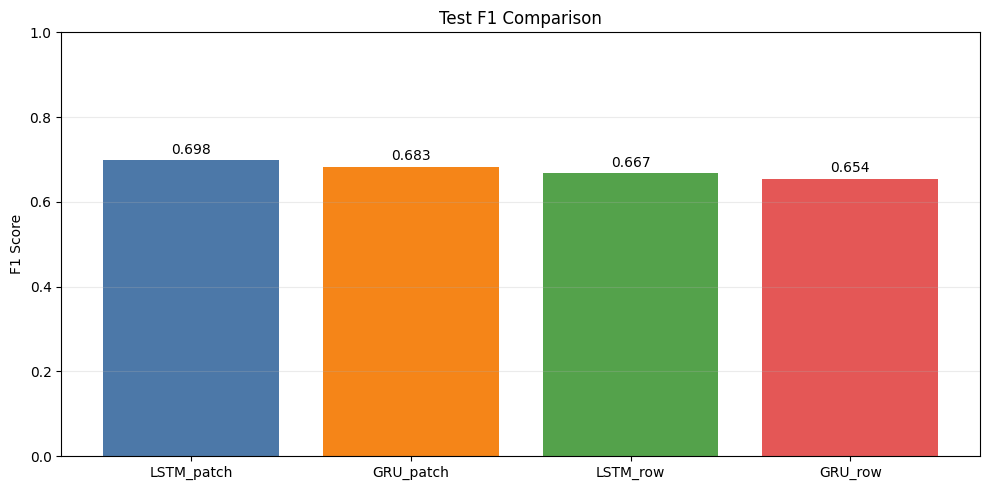

Saved: part5_detailed_metrics.png


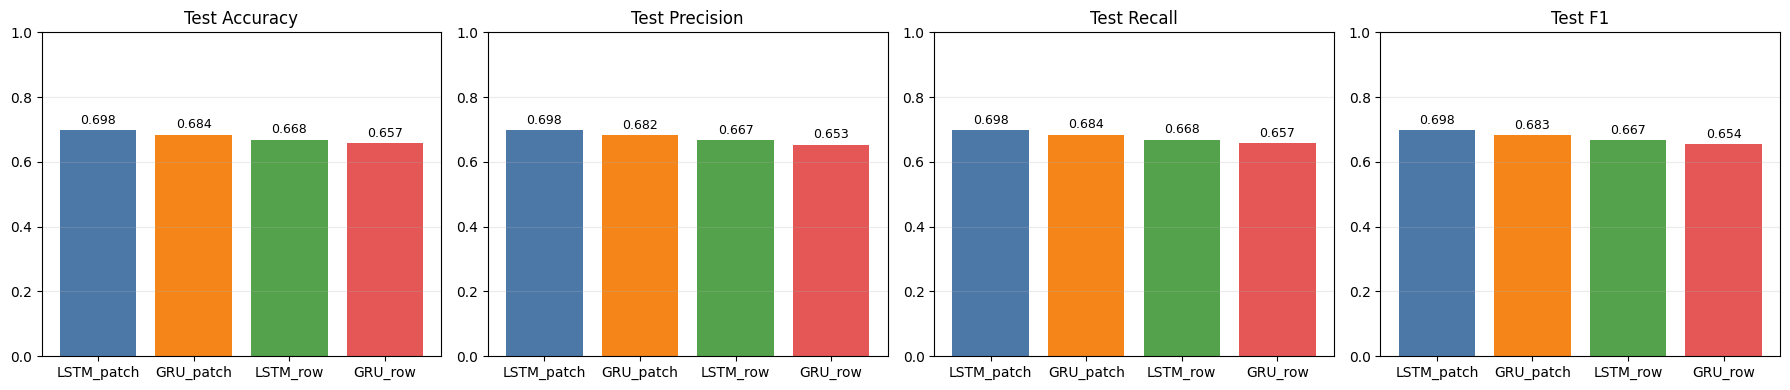


✓ All images saved to /Users/lyminhtrung/Library/CloudStorage/OneDrive-hcmut.edu.vn/DL-CV/CO5085_DeepLearning_CV/exercise/latex/images


,Model,Test Accuracy,Test Precision,Test Recall,Test F1
0,LSTM_patch,0.6983,0.698253,0.6983,0.697583
1,GRU_patch,0.6839,0.681997,0.6839,0.682629
2,LSTM_row,0.6678,0.667447,0.6678,0.667051
3,GRU_row,0.6571,0.653357,0.6571,0.654376


In [ ]:
import matplotlib.pyplot as plt
import os

# Create output directory for LaTeX images - notebook is in exercise/ so go up then into latex/images
output_dir = "./latex/images"
os.makedirs(output_dir, exist_ok=True)
output_dir = os.path.abspath(output_dir)
print(f"Saving images to: {output_dir}")

# all_histories được tạo sau khi chạy cell train.
if not all_histories:
    raise RuntimeError("all_histories đang rỗng. Hãy chạy cell train trước.")

metric_labels = {
    "train_loss": "Train Loss",
    "val_acc": "Validation Accuracy",
    "val_f1": "Validation F1",
}

# Vẽ learning curves cho từng model.
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for model_name, hist in all_histories.items():
    hist_df = pd.DataFrame(hist)
    for ax, key in zip(axes, ["train_loss", "val_acc", "val_f1"]):
        ax.plot(hist_df["epoch"], hist_df[key], marker="o", linewidth=2, label=model_name)
        ax.set_xlabel("Epoch")
        ax.set_title(metric_labels[key])
        ax.grid(alpha=0.25)

axes[0].set_ylabel("Value")
axes[0].legend(loc="best", fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "part5_learning_curves.png"), dpi=150, bbox_inches='tight')
print("Saved: part5_learning_curves.png")
plt.show()

# Nếu chưa có results_df thì tạo lại từ results.
if "results_df" not in globals():
    results_df = pd.DataFrame(results).sort_values(by="Test F1", ascending=False).reset_index(drop=True)

# Biểu đồ cột so sánh Test F1 giữa các model.
plt.figure(figsize=(10, 5))
bar_colors = ["#4C78A8", "#F58518", "#54A24B", "#E45756", "#72B7B2", "#EECA3B"]
plt.bar(results_df["Model"], results_df["Test F1"], color=bar_colors[:len(results_df)])
plt.title("Test F1 Comparison")
plt.ylabel("F1 Score")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.25)
for i, v in enumerate(results_df["Test F1"]):
    plt.text(i, min(v + 0.015, 0.99), f"{v:.3f}", ha="center", fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "part5_test_f1_comparison.png"), dpi=150, bbox_inches='tight')
print("Saved: part5_test_f1_comparison.png")
plt.show()

# Biểu đồ chi tiết so sánh các metrics
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
metrics = ["Test Accuracy", "Test Precision", "Test Recall", "Test F1"]
colors_list = ["#4C78A8", "#F58518", "#54A24B", "#E45756", "#72B7B2", "#EECA3B"]

for ax, metric in zip(axes, metrics):
    ax.bar(results_df["Model"], results_df[metric], color=colors_list[:len(results_df)])
    ax.set_title(f"{metric}")
    ax.set_ylim(0, 1)
    ax.grid(axis="y", alpha=0.25)
    for i, v in enumerate(results_df[metric]):
        ax.text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "part5_detailed_metrics.png"), dpi=150, bbox_inches='tight')
print("Saved: part5_detailed_metrics.png")
plt.show()

print(f"\n All images saved to {output_dir}")
results_df